# Assignment 6: RAG with Ollama

In this assignment, we explore **Retrieval-augmented generation (RAG)** with Large Language Models (LLMs). **This assignment is completely manually graded.**

Before you start, please be adivsed that you will need [Ollama](https://ollama.com/) and quite a few Python packages. It is therefore recommended that you use the [JupyterHub at Minerva cluster](https://git.chalmers.se/karppa/minerva/) as **Ollama is already running on the server**. See instructions behind the link to see how to gain access, and click [this](https://minerva.cse.chalmers.se/jupyter) to access the portal of Jupyter.

To run this assignment, you are going to need to install quite a few prerequisites. To maintain reproducibility, we will install the following packages through uv:
- `chromadb`
- `langchain`
- `langchain-chroma`
- `langchain-community`
- `langchain-ollama`
- `pypdf`

The following additional packages are needed if you want to use HuggingFace embedding models (optional):
- `langchain-huggingface`
- `sentence_transformers`

For simplicity, we provided a one-click installation script that will install all the required packages.

In [ ]:
import subprocess
import shutil
import os

SCRIPT = 'setup.ps1' if os.name == 'nt' else 'setup.sh'
URL = f'https://raw.githubusercontent.com/decogito/IntroDSAI-HA7/refs/heads/main/{SCRIPT}'

print(f'Downloading {SCRIPT}...')
os.system(f'curl -LsSf {URL} -o {SCRIPT}')

print(f'Running {SCRIPT}...')
if os.name == 'nt':
    os.system(f'powershell -ExecutionPolicy Bypass -File {SCRIPT}')
else:
    os.chmod(SCRIPT, 0o755)
    os.system(f'./{SCRIPT}')


**!!ATTENTION!! If this is your first time running the previous block, remember to (refresh the page and) switch to the `introdais-ha7` kernel. This will make the newly installed packages available in the notebook.**

Swtich the kernel by clicking on the kernel name in the top right corner of the notebook, and selecting `introdais-ha7` from the dropdown menu. You should see the kernel name change:

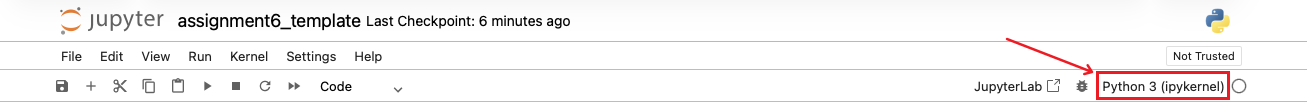

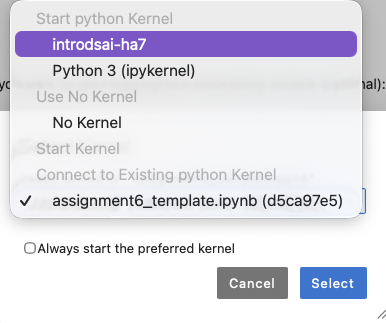

Then restart the kernel:

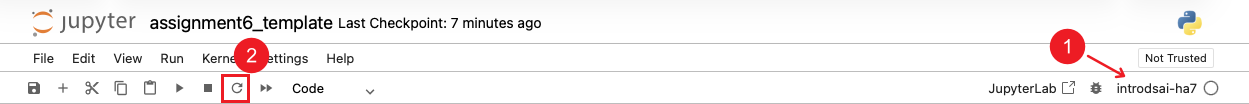

In [ ]:
## Uninstallation — uncomment and run to remove uv and the local environment

# import os
# SCRIPT = 'uninstall.ps1' if os.name == 'nt' else 'uninstall.sh'
# URL = f'https://raw.githubusercontent.com/decogito/IntroDSAI-HA7/refs/heads/main/{SCRIPT}'

# print(f'Downloading {SCRIPT}...')
# os.system(f'curl -LsSf {URL} -o {SCRIPT}')

# print(f'Running {SCRIPT}...')
# if os.name == 'nt':
#     os.system(f'powershell -ExecutionPolicy Bypass -File {SCRIPT}')
# else:
#     os.chmod(SCRIPT, 0o755)
#     os.system(f'./{SCRIPT}')


Finally, you will need to install [Ollama](https://ollama.com/). It is also available through Conda, but the version served there is rather dated and does not support newer LLMs (it works fine with [Mistral](https://mistral.ai/) 7B, though).

Ollama is open source server software that runs LLMs locally on your computer. You can choose which LLM you want to use. By default, the code below uses [Llama](https://www.llama.com/) 3.2 3B, but if this is slow, you can switch to Llama 3.2 1B, or if you want to use an European model (or want to use an older version of Ollama), you can try Mistral 7B.

## Introduction

Below, you can see a class that has been named `RAGAssistant`. It provides a convenient access to try out RAG. It works as follows:
- The constructor simply initializes the class (nothing fancy).
- `add_document(filename)` adds the given document file into the database. The document must either be raw UTF-8 text (`.txt`) or a PDF file (`.pdf`). What it does is that it extracts the text from the document, converts it into chunks, embeds them into an LLM vector space, and then stores them in a [Chroma](https://www.trychroma.com/) database.
- `query(query_text)` queries the database using the specified LLM. What it does is that it first queries the closest documents matching the query from the database, injects these as a context into the prompt presented to the LLM, and then presents the query to the LLM.
- `reset()` resets the database.

The class can be used in an interactive fashion, so once you've added documents, you can start making as many queries you want. When you want to remove the documents from the database, just use `reset`, and add some new documents instead.

The choice of the LLM is controlled by the variable `LLM`.

**If you are running Ollama locally**, you must `pull` the LLM by issuing the following command on the command line:

```sh
ollama pull llm-name
```

E.g., `ollama pull llama3.2:3b` pulls (dowloads from the Internet) the default LLM we might want to use.

You will need to install at least the following model, which is used to compute text embeddings:

```sh
ollama pull all-minilm:22m
```

The following models have been installed on Minerva:
- `mistral:7b`
- `llama3.1:8b`
- `llama3.2:1b`
- `llama3.2:3b`
- `all-minilm:22m` (used to compute embeddings only)

The system is very simple and does not, for example, contain any memory to process multiple queries. However, it is very easy to extend this to more complex applications.

**Beware:** LLMs are very computationally demanding, and the queries may be slow. Furthermore, in some cases, the queries can take an extraordinary amount of time in which case it might be wise to interrupt the query and rephrase. `llama3.2:1b` is probably the fastest of the bunch, which of course means that it performs the poorest, but any one will do for our purposes.

**Beware:** Adding documents into the database can take a lot of time because of the expensive embedding computations. When testing the Question 3 on Minerva, it took **over 7 minutes** to add the entire dataset (all PDF files). **This is normal.** However, you only need to add the documents once during a session and then you can query as many prompts as you wish.

In [ ]:
# Uncomment to download the models. Here, we use all-minilm:22m and llama3.2:3b as the example.
# Uses subprocess so it works cross-platform even if ollama is not on the system PATH.

def ollama_pull(model):
    # Search for the ollama binary: PATH first, then platform-specific default locations
    ollama_bin = shutil.which("ollama")
    if ollama_bin is None:
        if os.name == "nt":  # Windows
            candidates = [os.path.expandvars(r"%LOCALAPPDATA%\Programs\Ollama\ollama.exe")]
        else:  # macOS / Linux (including snap)
            candidates = ["/usr/local/bin/ollama", "/snap/bin/ollama"]
        ollama_bin = next((p for p in candidates if os.path.isfile(p)), None)
    if ollama_bin is None:
        raise FileNotFoundError("ollama not found. Please install it from https://ollama.com/")
    subprocess.run([ollama_bin, "pull", model], check=True)

# ollama_pull('all-minilm:22m')
# ollama_pull('llama3.2:3b')

In [ ]:
from langchain_community.document_loaders.pdf import PyPDFLoader, PyPDFDirectoryLoader
from langchain_community.document_loaders.text import TextLoader
#from langchain_huggingface import HuggingFaceEmbeddings # Uncomment this to use HF embeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma.vectorstores import Chroma
from langchain_core.prompts import ChatPromptTemplate
from langchain_ollama import ChatOllama, OllamaEmbeddings

class RAGAssistant:
    """
    Performs queries about documents using an LLM via Ollama
    """

    CHROMA_PATH = 'chroma'
    HF_EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
    OLLAMA_EMBEDDING_MODEL_NAME = "all-minilm:22m"
    EMBEDDING_MODEL_TYPE = "ollama" # Use Ollama embeddings (default)
    #EMBEDDING_MODEL_TYPE = "hf"    # Use HuggingFace embeddings
    PROMPT_TEMPLATE = """
    Answer the question based only on the following context:

    {context}

    ---

    Answer the question based on the above context: {question}
    """
    # LLM = 'mistral:7b'
    # LLM = 'llama3.1:8b'
    LLM = 'llama3.2:3b'
    # LLM = 'llama3.2:1b'

    def __init__(self):
        """
        Initialization: simply reset the database (remove it)
        """
        self.text_splitter = RecursiveCharacterTextSplitter(
            chunk_size=512,
            chunk_overlap=80,
            length_function=len,
            is_separator_regex=False,
        )
        self.reset()


    def reset(self):
        """
        Empties the database
        """
        self.db = Chroma(embedding_function = self.get_embedding_function())
        self.db.reset_collection()


    def add_document(self, filename):
        """
        Adds the given document into the database. The file must be either a PDF or a .txt file.
        If filename has no extension, it is assumed to be a directory and all PDF files are loaded
        from the directory.
        """
        if filename.endswith('.pdf'):
            documents = PyPDFLoader(filename).load()
        elif filename.endswith('.txt'):
            documents = TextLoader(filename).load()
        elif os.path.isdir(filename):
            documents = PyPDFDirectoryLoader(filename).load()
        else:
            raise ValueError(
                "Filename must end in either .pdf or .txt, or be a directory, "
                f"but got '{filename}'"
            )

        chunks = self.text_splitter.split_documents(documents)

        chunks_with_ids = self.calculate_chunk_ids(chunks)

        existing_items = self.db.get(include=[])
        existing_ids = set(existing_items["ids"])

        # Only add documents that don't exist in the DB.
        new_chunks = []
        for chunk in chunks_with_ids:
            if chunk.metadata["id"] not in existing_ids:
                new_chunks.append(chunk)

        if len(new_chunks):
            new_chunk_ids = [chunk.metadata["id"] for chunk in new_chunks]
            self.db.add_documents(new_chunks, ids=new_chunk_ids)


    def calculate_chunk_ids(self, chunks):
        """
        Helper function for computing chunk ids
        """
        last_page_id = None
        current_chunk_index = 0

        for chunk in chunks:
            source = chunk.metadata.get("source")
            page = chunk.metadata.get("page")
            current_page_id = f"{source}:{page}"
            if current_page_id == last_page_id:
                current_chunk_index += 1
            else:
                current_chunk_index = 0
            chunk_id = f"{current_page_id}:{current_chunk_index}"
            last_page_id = current_page_id
            chunk.metadata["id"] = chunk_id

        return chunks

    def get_embedding_function(self):
        """
        Helper function for simply returning the same embedding function always
        """
        if self.EMBEDDING_MODEL_TYPE == "ollama":
            embedding_function = OllamaEmbeddings(model=self.OLLAMA_EMBEDDING_MODEL_NAME)
        elif self.EMBEDDING_MODEL_TYPE == "hf":
            embedding_function = HuggingFaceEmbeddings(model_name=self.HF_EMBEDDING_MODEL_NAME)
        else:
            raise ValueError(f"unknown embedding model type: {self.EMBEDDING_MODEL_TYPE}")
        return embedding_function

    def query(self, query_text):
        """
        Performs the RAG query.

        First, queries the database for the most relevant documents.

        Then, injects the documents into the prompt.

        Finally, invokes the LLM to answer the prompt within the context.

        Return value: (response, sources) where response is a string and sources is a list of sources
        """

        results = self.db.similarity_search_with_score(query_text, k=5)
        context_text = "\n\n---\n\n".join([doc.page_content for doc, _score in results])
        prompt_template = ChatPromptTemplate.from_template(self.PROMPT_TEMPLATE)
        prompt = prompt_template.format(context=context_text, question=query_text)

        model = ChatOllama(model = self.LLM)
        response_text = model.invoke(prompt)

        sources = [doc.metadata.get("id", None) for doc, _score in results]
        return (response_text.content,sources)


# this is the object we're going to manipulate
rag = RAGAssistant()

## Question 1: EU AI Act

The file `ai_act_en.pdf` (available on Canvas) contains the text of the EU AI Act in English. Use your `rag` object to add the file into the database. Then, choose a question you think is interesting regarding the AI act and explore what the model says about it.

Potential themes can be the aims of the AI act, the impact that the act has on businesses, the impact on particular industries (such as healthcare or finance), or potential issues with the act, or something completely different but relevant. Don't know about the AI act? Now it's time to find out.

Check what documents the model has used for sources. Do the cited sources support the claims the model makes? Once you've probed your model about the act, cross-reference the models answers with other sources you can find online. Do they confirm what the model is saying or are they contradictory, or are the model's answers even nonsensical?

Write 2–4 paragraphs. Include in your answer at least one prompt and answer that your model gave you. Cite the sources you used to confirm or contradict what the model claims.

*Write your answer here*

In [ ]:
# you can use as many code cells here as you want, this is manually graded

## Question 2: The Coffee Brewer

You have bought a new coffee brewer, but, unfortunately, they only sent the operating instructions in Finnish. The instructions are available in `moccamaster_manual_fi.pdf` (available on Canvas).

Add the document into `rag` and probe it to find out how to operate your coffee machine. Ask questions about things such as safety, operating, and cleaning of the machine, or what one should do if the machine breaks. In light of your understanding of coffee brewers and home appliances in general, do the answers make sense? Discuss and include at least one prompt and one answer from the LLM as part of your answer. Write 2–4 paragraphs.

*Write your answer here*

## Question 3: UFO files

The file `ufo_files.zip` (available on Canvas) contains declassified CIA files pertaining to CIA's investigation into unidentified flying objects (UFOs).

Extract the package and add the documents into your `rag`. Then, query whatever you think would be interesting to ask about the documents, such as where and when sightings have occurred, have there been spikes, does the collection contain information about publicly famous cases (such as the Roswell Incident), about governmental programs relating to UFOs, patterns in sightings, international relations, and so on.

Look at the sources the model provides you. Do the sources support the inferences made by the model? Discuss, and again include at least one prompt and response pair. Write 2–4 paragraphs.

## Question 4: Your own data

Provide some documents of your own to the system. The data can be arbitrary, but preferably something that is widely not considered publicly available or googleable. It can be also something completely made up for the purpose, like a short story. **Suggestion:** If you come from another discipline than computer science or data science, try using some data within your own discipline. Perhaps a suitable research article? Anything will do.

Present meaningful questions that can be answered with the data, and discuss the results. Write 2–4 paragraphs and again include at least one prompt and response pair.

*Write your answer here*